https://medium.com/python-programming-ascendance/my-first-image-generation-gan-network-results-and-python-code-10a0857f09dd

# 🎨 Generative Adversarial Networks (GAN) — Generación de Imágenes

## ¿Qué es una GAN?

Una **GAN** es un sistema de dos redes neuronales que se entrenan en competición mutua:

```
Ruido aleatorio (z) ──→ [GENERADOR G] ──→ Imagen falsa ──→ ┐
                                                              ├─→ [DISCRIMINADOR D] ──→ ¿Real o Falsa?
Imágenes reales ────────────────────────────────────────────→ ┘
```

**Analogía**: el Generador es un falsificador de cuadros, el Discriminador es un experto en arte. El falsificador mejora intentando engañar al experto; el experto mejora al ver más falsificaciones.

### El equilibrio de Nash

El entrenamiento converge (teóricamente) cuando el Generador produce imágenes tan buenas que el Discriminador no puede distinguirlas de las reales: **P(real | imagen generada) = 0.5**

---
## 📐 Arquitectura de esta GAN: DCGAN

Usamos una **Deep Convolutional GAN (DCGAN)**, que reemplaza las capas Dense por capas convolucionales:
- El **Generador** usa `Conv2DTranspose` (deconvoluciones) para ir ampliando el tamaño de la imagen
- El **Discriminador** usa `Conv2D` con stride=2 para ir reduciendo el tamaño

Esto es mucho más estable que usar solo capas Dense y produce imágenes de mayor calidad.

#adaptar a 128x128

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, LeakyReLU, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

In [2]:
import os
os.getcwd()

'c:\\Users\\tomas\\ML\\Master Data Science and AI\\09 Deep Learning'

---
## 🏗️ Parte 1: El Generador

El Generador transforma un **vector de ruido aleatorio** (100 dimensiones) en una imagen de 128×128×3 píxeles.

El proceso es de menor a mayor resolución — como "esculpir" la imagen:

```
Ruido (100,)
    ↓  Dense
(8, 8, 256) — "semilla visual" de baja resolución
    ↓  Conv2DTranspose ×2
(16, 16, 128) → (32, 32, 128) → (64, 64, 64)
    ↓  Conv2DTranspose final
(128, 128, 3) — imagen RGB final, valores en [-1, 1] por la activación tanh
```

**`use_bias=False`**: cuando se usa BatchNormalization, el bias es redundante (la BN tiene su propio parámetro de desplazamiento β).

---
## 🏗️ Parte 2: El Discriminador

El Discriminador es una CNN clásica que **clasifica si una imagen es real o falsa**.

Recorre el proceso inverso al Generador:

```
Imagen (128, 128, 3)
    ↓  Conv2D + LeakyReLU + Dropout ×4
(64, 64, 64) → (32, 32, 128) → (16, 16, 128) → (8, 8, 128)
    ↓  Flatten
Vector de 8192 dimensiones
    ↓  Dense(1) sin activación — logits
Puntuación real/falso
```

**`LeakyReLU`**: a diferencia de ReLU (que mata neuronas con valores negativos), LeakyReLU deja pasar un pequeño gradiente negativo (pendiente = 0.2). Esto es importante para la estabilidad del entrenamiento de GANs.

**`Dropout(0.3)`**: regularización para que el Discriminador no memorice las imágenes reales.

---
## 📉 Funciones de Pérdida

La clave del entrenamiento adversarial son dos funciones de pérdida opuestas:

### Pérdida del Discriminador
Quiere clasificar correctamente **ambos tipos**:
- Imágenes reales → predecir `1`
- Imágenes falsas → predecir `0`

```python
loss_D = loss(1, D(x_real)) + loss(0, D(G(z)))
```

### Pérdida del Generador
Quiere que el Discriminador **clasifique sus imágenes como reales**:
```python
loss_G = loss(1, D(G(z)))
```

> ⚠️ **Problema de equilibrio**: si el Discriminador es demasiado bueno demasiado rápido, el Generador no recibe gradientes útiles (el gradiente es casi cero). Si el Generador es demasiado bueno, el Discriminador colapsa. Balancear ambas redes es el mayor reto de entrenar GANs.

In [3]:
def load_images(data_folder):
    image_files = glob.glob(data_folder + '/*.jpg')
    images = []
    for file in image_files:
        image = Image.open(file)
        image = image.resize((64, 64))  # Resize to a manageable size
        image = image.resize((128, 128))  # Resize to a manageable size
        image = np.array(image)
        images.append(image)
    images = np.array(images)
    images = (images - 127.5) / 127.5  # Normalize images to [-1, 1]
    return images




def build_generator():
    model = Sequential()

    # Vector de entrada: ruido de tamaño 100 → 8x8x256
    model.add(Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(LeakyReLU())
    model.add(Reshape((8, 8, 256)))

    # 8x8x256 → 16x16x128
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 16x16x128 → 32x32x128
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 32x32x128 → 64x64x64
    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 64x64x64 → 128x128x3
    model.add(Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', 
                              use_bias=False, activation='tanh'))

    return model


def build_discriminator():
    model = Sequential()

    # 128x128x3 → 64x64x64
    model.add(Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                     input_shape=(128, 128, 3)))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 64x64x64 → 32x32x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 32x32x128 → 16x16x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 16x16x128 → 8x8x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # Aplanado → salida final
    model.add(Flatten())
    model.add(Dense(1))  # Salida tipo logits (para usar con `from_logits=True`)

    return model




def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)





**Generador**

El generador de una GAN (Generative Adversarial Network) es como un artista imaginario: intenta crear imágenes (o cualquier otro tipo de datos) tan realistas que el discriminador no pueda decir si son falsas o verdaderas.  


Toma un vector de ruido aleatorio (por ejemplo, 100 valores sin sentido) y lo convierte en una imagen estructurada y coherente.  

Aprende a imitar las características visuales del conjunto de datos original.

Cuanto más entrena, más “creativa” y precisa se vuelve al generar resultados difíciles de distinguir de los reales.

* Dense(8*8*256)	(8, 8, 256)	Convierte el vector 1D (de tamaño 100) en una "semilla visual" tridimensional.
* LeakyReLU()	(8, 8, 256)	Agrega no linealidad para que la red pueda aprender formas más complejas.
* Reshape((8, 8, 256))	(8, 8, 256)	Rearma el vector plano en un pequeño volumen tipo imagen inicial.
* Conv2DTranspose(128)	(16, 16, 128)	Primera “escalada” de la imagen usando filtros para crear patrones visuales.
* LeakyReLU()	(16, 16, 128)	Añade activación no lineal.
* Conv2DTranspose(128)	(32, 32, 128)	Segunda escalada: la imagen crece en tamaño y detalles.
* LeakyReLU()	(32, 32, 128)	Mantiene diversidad en los patrones generados.
* Conv2DTranspose(64)	(64, 64, 64)	Tercera escalada: disminuye número de filtros y agranda resolución.
* LeakyReLU()	(64, 64, 64)	Sigue aportando capacidad expresiva.
* Conv2DTranspose(3, tanh)	(128, 128, 3)	Última capa: genera imagen RGB y normaliza píxeles entre -1 y 1 (tanh).  

**Discriminador**  
  
* Conv2D(64) + LeakyReLU	(64×64×64)	Extrae patrones simples (bordes, colores) mientras reduce resolución.  
* Dropout(0.3)	(64×64×64)	Evita que el modelo se sobreentrene; “desactiva” neuronas al azar.
* Conv2D(128) + LeakyReLU	(32×32×128)	Capta estructuras más complejas como formas o texturas.
* Dropout(0.3)	(32×32×128)	Sigue regularizando el aprendizaje.
* Conv2D(128) + LeakyReLU	(16×16×128)	Extrae relaciones espaciales más abstractas.
* Dropout(0.3)	(16×16×128)	Previene que memorice patrones específicos.
* Conv2D(128) + LeakyReLU	(8×8×128)	Último nivel de compresión: sintetiza la imagen en características clave.
* Dropout(0.3)	(8×8×128)	Última barrera contra el sobreajuste.
* Flatten()	(8192,)	Convierte todo a un vector plano para tomar una decisión final.
* Dense(1)	(1,)	Emite un escalar: valor alto = parece real, valor bajo = parece falso. --> al emplear la funcion de persida bin entropy esta espera una salida logit, por ello no se emplea aqui una salida sogmoid

Data set de fachadas de edificios  
https://www.tensorflow.org/tutorials/generative/pix2pix?hl=es-419

In [4]:
data_folder = './images/LZ'
#data_folder = './images/fachadas'
images = load_images(data_folder)

In [5]:
def show_image(img):
    img = (img * 127.5) + 127.5
    img = img.astype(np.uint8)  # Convertir a tipo de datos adecuado para mostrar

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")  # Opcional: oculta los ejes
    plt.show()

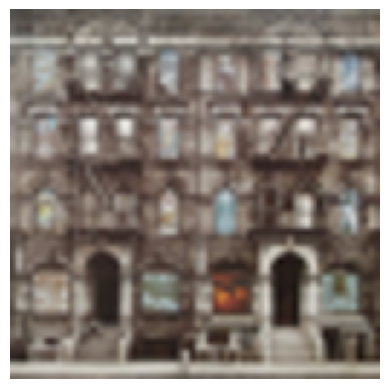

In [6]:
 show_image(images[1])

In [7]:
generator_optimizer = Adam(1e-4)
discriminator_optimizer = Adam(1e-4)
# This method returns a helper function to compute cross entropy loss


---
## 🏗️ Parte 1: El Generador

El Generador transforma un **vector de ruido aleatorio** (100 dimensiones) en una imagen de 128×128×3 píxeles.

El proceso es de menor a mayor resolución — como "esculpir" la imagen:

```
Ruido (100,)
    ↓  Dense
(8, 8, 256) — "semilla visual" de baja resolución
    ↓  Conv2DTranspose ×2
(16, 16, 128) → (32, 32, 128) → (64, 64, 64)
    ↓  Conv2DTranspose final
(128, 128, 3) — imagen RGB final, valores en [-1, 1] por la activación tanh
```

**`use_bias=False`**: cuando se usa BatchNormalization, el bias es redundante (la BN tiene su propio parámetro de desplazamiento β).

---
## 🏗️ Parte 2: El Discriminador

El Discriminador es una CNN clásica que **clasifica si una imagen es real o falsa**.

Recorre el proceso inverso al Generador:

```
Imagen (128, 128, 3)
    ↓  Conv2D + LeakyReLU + Dropout ×4
(64, 64, 64) → (32, 32, 128) → (16, 16, 128) → (8, 8, 128)
    ↓  Flatten
Vector de 8192 dimensiones
    ↓  Dense(1) sin activación — logits
Puntuación real/falso
```

**`LeakyReLU`**: a diferencia de ReLU (que mata neuronas con valores negativos), LeakyReLU deja pasar un pequeño gradiente negativo (pendiente = 0.2). Esto es importante para la estabilidad del entrenamiento de GANs.

**`Dropout(0.3)`**: regularización para que el Discriminador no memorice las imágenes reales.

In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator=build_generator()
discriminator=build_discriminator()

c:\Users\tomas\envs\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\tomas\envs\dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
import os

# Contar archivos .jpg (ignorando mayúsculas/minúsculas)
num_jpg = sum(
    1 for fichero in os.listdir(data_folder)
    if fichero.lower().endswith(".jpg")
)

print(f"Número de archivos JPG: {num_jpg}")


Número de archivos JPG: 8


---
## ⏱️ Configuración del entrenamiento

Con imágenes de 128×128 y pocas imágenes de entrenamiento, el modelo necesita muchas épocas para generar algo coherente.

**Indicadores de que el entrenamiento va bien:**
- Las pérdidas del Generador y Discriminador oscilan pero no colapsan a 0
- Las imágenes generadas cada 50 épocas muestran progresión visual
- El Discriminador no llega a accuracy del 100% (señal de que el Generador mejora)

**Problemas comunes en GANs:**
- **Mode collapse**: el Generador aprende a producir siempre la misma imagen
- **Discriminator collapse**: el Discriminador se vuelve demasiado bueno y el Generador no aprende
- **Entrenamiento inestable**: las pérdidas oscilan de forma errática

In [10]:
EPOCHS = 5000
noise_dim = 100
#num_examples_to_generate = 16
num_examples_to_generate = 16
# We will reuse this seed overtime (so it's easier to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

Buffer es el tamaño de la memoria virtual que TensorFlow usará para mezclar aleatoriamente los datos. Se puede coger un buffer aslgo mayor que el numero de imagenes para asegurarnos de que coge todas las imagenes para la mezcla

In [11]:
BUFFER_SIZE = 10
BATCH_SIZE = 10

---
## 📉 Funciones de Pérdida

La clave del entrenamiento adversarial son dos funciones de pérdida opuestas:

### Pérdida del Discriminador
Quiere clasificar correctamente **ambos tipos**:
- Imágenes reales → predecir `1`
- Imágenes falsas → predecir `0`

```python
loss_D = loss(1, D(x_real)) + loss(0, D(G(z)))
```

### Pérdida del Generador
Quiere que el Discriminador **clasifique sus imágenes como reales**:
```python
loss_G = loss(1, D(G(z)))
```

> ⚠️ **Problema de equilibrio**: si el Discriminador es demasiado bueno demasiado rápido, el Generador no recibe gradientes útiles (el gradiente es casi cero). Si el Generador es demasiado bueno, el Discriminador colapsa. Balancear ambas redes es el mayor reto de entrenar GANs.

---
## 🎓 El bucle de entrenamiento: `train_step`

Este es el corazón de la GAN. En cada step:

1. **Generar ruido** `z ~ N(0,1)` 
2. **Forward pass** del Generador: `G(z)` → imagen falsa
3. **Forward pass** del Discriminador sobre imágenes reales y falsas
4. **Calcular pérdidas** de Generador y Discriminador
5. **Backpropagation separada**: los gradientes del Generador NO afectan al Discriminador y viceversa

`tf.GradientTape` registra todas las operaciones para calcular los gradientes automáticamente.

> 💡 **Truco importante**: el Generador y el Discriminador se actualizan con la misma frecuencia. En algunos problemas se actualiza el Discriminador varias veces por cada update del Generador.

In [12]:
# @tf.function #grafo computacional 
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim]) # genera el ruido, crea vectores aleatorios para alimentar al generador.

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))



def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, :] * 0.5 + 0.5)

        plt.axis('off')
        if (epoch%50==0):
          plt.savefig('./images_new/image_at_epoch_{:04d}.png'.format(epoch))
    plt.close()


def upscale_and_save(image_array, scale_factor=4, output_path='output.png'):
    image = Image.fromarray(image_array)
    new_size = (image.width * scale_factor, image.height * scale_factor)
    upscaled = image.resize(new_size, resample=Image.NEAREST)  # o Image.BICUBIC para suavizado
    upscaled.save(output_path)


def generate_and_save_single_image(model, epoch, test_input):
    if epoch % 50 == 0:
        predictions = model(test_input, training=False)

        image = predictions[0]
        image = (image * 127.5 + 127.5).numpy().astype(np.uint8)

        upscale_and_save(image, scale_factor=8, output_path=f'./images_new/image_{epoch:04d}.png')



def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF as we go
        #generate_and_save_images(generator, epoch + 1, seed)
        generate_and_save_single_image(generator, epoch + 1, seed)

        
        # Save the model every epoch

        if epoch % 100 == 0:
            generator.save(f'./generator_epoch_{epoch+1}.h5')
            discriminator.save(f'./discriminator_epoch_{epoch+1}.h5')  # Corregido: antes ponías epoch+51 por error

        
        print(f'Epoch {epoch+1} completed')


**Entrenamiento**  

GradientTape() actua como un grabador. Usa dos "cintas" una para grabar que hace el generador y otra para lo que hace el discrminador.  
El generador intenta crear imágenes realistas a partir del ruido.  
El discriminador debe clasificar cada tipo correctamente.  
El generador quiere que las imágenes falsas parezcan reales (fake_output → 1).  
El discriminador quiere distinguir correctamente (real_output → 1, fake_output → 0).  
Se actualizan los pesos de ambas redes con sus respectivos gradientes.  

In [13]:

# Replace this with your model's filepath
#model_filepath = './generator_epoch_50.h5'

# Load the model
#model = tf.keras.models.load_model(model_filepath)
#model.compile(optimizer='adam',
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])


# Batch and shuffle the data

train_dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [14]:
train_dataset

<_BatchDataset element_spec=TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float64, name=None)>

In [15]:
# Train the model
train(train_dataset, EPOCHS)

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed
Epoch 51 completed
Epoch 52 completed
Epoch 53 completed
Ep

Epoch 101 completed
Epoch 102 completed
Epoch 103 completed
Epoch 104 completed
Epoch 105 completed
Epoch 106 completed
Epoch 107 completed
Epoch 108 completed
Epoch 109 completed
Epoch 110 completed
Epoch 111 completed
Epoch 112 completed
Epoch 113 completed
Epoch 114 completed
Epoch 115 completed
Epoch 116 completed
Epoch 117 completed
Epoch 118 completed
Epoch 119 completed
Epoch 120 completed
Epoch 121 completed
Epoch 122 completed
Epoch 123 completed
Epoch 124 completed
Epoch 125 completed
Epoch 126 completed
Epoch 127 completed
Epoch 128 completed
Epoch 129 completed
Epoch 130 completed
Epoch 131 completed
Epoch 132 completed
Epoch 133 completed
Epoch 134 completed
Epoch 135 completed
Epoch 136 completed
Epoch 137 completed
Epoch 138 completed
Epoch 139 completed
Epoch 140 completed
Epoch 141 completed
Epoch 142 completed
Epoch 143 completed
Epoch 144 completed
Epoch 145 completed
Epoch 146 completed
Epoch 147 completed
Epoch 148 completed
Epoch 149 completed
Epoch 150 completed


Epoch 201 completed
Epoch 202 completed
Epoch 203 completed
Epoch 204 completed
Epoch 205 completed
Epoch 206 completed
Epoch 207 completed
Epoch 208 completed
Epoch 209 completed
Epoch 210 completed
Epoch 211 completed
Epoch 212 completed
Epoch 213 completed
Epoch 214 completed
Epoch 215 completed
Epoch 216 completed
Epoch 217 completed
Epoch 218 completed
Epoch 219 completed
Epoch 220 completed
Epoch 221 completed
Epoch 222 completed
Epoch 223 completed
Epoch 224 completed
Epoch 225 completed
Epoch 226 completed
Epoch 227 completed
Epoch 228 completed
Epoch 229 completed
Epoch 230 completed
Epoch 231 completed
Epoch 232 completed
Epoch 233 completed
Epoch 234 completed
Epoch 235 completed
Epoch 236 completed
Epoch 237 completed
Epoch 238 completed
Epoch 239 completed
Epoch 240 completed
Epoch 241 completed
Epoch 242 completed
Epoch 243 completed
Epoch 244 completed
Epoch 245 completed
Epoch 246 completed
Epoch 247 completed
Epoch 248 completed
Epoch 249 completed
Epoch 250 completed


Epoch 301 completed
Epoch 302 completed
Epoch 303 completed
Epoch 304 completed
Epoch 305 completed
Epoch 306 completed
Epoch 307 completed
Epoch 308 completed
Epoch 309 completed
Epoch 310 completed
Epoch 311 completed
Epoch 312 completed
Epoch 313 completed
Epoch 314 completed
Epoch 315 completed
Epoch 316 completed
Epoch 317 completed
Epoch 318 completed
Epoch 319 completed
Epoch 320 completed
Epoch 321 completed
Epoch 322 completed
Epoch 323 completed
Epoch 324 completed
Epoch 325 completed
Epoch 326 completed
Epoch 327 completed
Epoch 328 completed
Epoch 329 completed
Epoch 330 completed
Epoch 331 completed
Epoch 332 completed
Epoch 333 completed
Epoch 334 completed
Epoch 335 completed
Epoch 336 completed
Epoch 337 completed
Epoch 338 completed
Epoch 339 completed
Epoch 340 completed
Epoch 341 completed
Epoch 342 completed
Epoch 343 completed
Epoch 344 completed
Epoch 345 completed
Epoch 346 completed
Epoch 347 completed
Epoch 348 completed
Epoch 349 completed
Epoch 350 completed


Epoch 401 completed
Epoch 402 completed
Epoch 403 completed
Epoch 404 completed
Epoch 405 completed
Epoch 406 completed
Epoch 407 completed
Epoch 408 completed
Epoch 409 completed
Epoch 410 completed
Epoch 411 completed
Epoch 412 completed
Epoch 413 completed
Epoch 414 completed
Epoch 415 completed
Epoch 416 completed
Epoch 417 completed
Epoch 418 completed
Epoch 419 completed
Epoch 420 completed
Epoch 421 completed
Epoch 422 completed
Epoch 423 completed
Epoch 424 completed
Epoch 425 completed
Epoch 426 completed
Epoch 427 completed
Epoch 428 completed
Epoch 429 completed
Epoch 430 completed
Epoch 431 completed
Epoch 432 completed
Epoch 433 completed
Epoch 434 completed
Epoch 435 completed
Epoch 436 completed
Epoch 437 completed
Epoch 438 completed
Epoch 439 completed
Epoch 440 completed
Epoch 441 completed
Epoch 442 completed
Epoch 443 completed
Epoch 444 completed
Epoch 445 completed
Epoch 446 completed
Epoch 447 completed
Epoch 448 completed
Epoch 449 completed
Epoch 450 completed


...

Epoch 2001 completed
Epoch 2002 completed
Epoch 2003 completed
Epoch 2004 completed
Epoch 2005 completed
Epoch 2006 completed
Epoch 2007 completed
Epoch 2008 completed
Epoch 2009 completed
Epoch 2010 completed
Epoch 2011 completed
Epoch 2012 completed
Epoch 2013 completed
Epoch 2014 completed
Epoch 2015 completed
Epoch 2016 completed
Epoch 2017 completed
Epoch 2018 completed
Epoch 2019 completed
Epoch 2020 completed
Epoch 2021 completed
Epoch 2022 completed
Epoch 2023 completed
Epoch 2024 completed
Epoch 2025 completed
Epoch 2026 completed
Epoch 2027 completed
Epoch 2028 completed
Epoch 2029 completed
Epoch 2030 completed
Epoch 2031 completed
Epoch 2032 completed
Epoch 2033 completed
Epoch 2034 completed
Epoch 2035 completed
Epoch 2036 completed
Epoch 2037 completed
Epoch 2038 completed
Epoch 2039 completed
Epoch 2040 completed
Epoch 2041 completed
Epoch 2042 completed
Epoch 2043 completed
Epoch 2044 completed
Epoch 2045 completed
Epoch 2046 completed
Epoch 2047 completed
Epoch 2048 co

Epoch 2101 completed
Epoch 2102 completed
Epoch 2103 completed
Epoch 2104 completed
Epoch 2105 completed
Epoch 2106 completed
Epoch 2107 completed
Epoch 2108 completed
Epoch 2109 completed
Epoch 2110 completed
Epoch 2111 completed
Epoch 2112 completed
Epoch 2113 completed
Epoch 2114 completed
Epoch 2115 completed
Epoch 2116 completed
Epoch 2117 completed
Epoch 2118 completed
Epoch 2119 completed
Epoch 2120 completed
Epoch 2121 completed
Epoch 2122 completed
Epoch 2123 completed
Epoch 2124 completed
Epoch 2125 completed
Epoch 2126 completed
Epoch 2127 completed
Epoch 2128 completed
Epoch 2129 completed
Epoch 2130 completed
Epoch 2131 completed
Epoch 2132 completed
Epoch 2133 completed
Epoch 2134 completed
Epoch 2135 completed
Epoch 2136 completed
Epoch 2137 completed
Epoch 2138 completed
Epoch 2139 completed
Epoch 2140 completed
Epoch 2141 completed
Epoch 2142 completed
Epoch 2143 completed
Epoch 2144 completed
Epoch 2145 completed
Epoch 2146 completed
Epoch 2147 completed
Epoch 2148 co

Epoch 2201 completed
Epoch 2202 completed
Epoch 2203 completed
Epoch 2204 completed
Epoch 2205 completed
Epoch 2206 completed
Epoch 2207 completed
Epoch 2208 completed
Epoch 2209 completed
Epoch 2210 completed
Epoch 2211 completed
Epoch 2212 completed
Epoch 2213 completed
Epoch 2214 completed
Epoch 2215 completed
Epoch 2216 completed
Epoch 2217 completed
Epoch 2218 completed
Epoch 2219 completed
Epoch 2220 completed
Epoch 2221 completed
Epoch 2222 completed
Epoch 2223 completed
Epoch 2224 completed
Epoch 2225 completed
Epoch 2226 completed
Epoch 2227 completed
Epoch 2228 completed
Epoch 2229 completed
Epoch 2230 completed
Epoch 2231 completed
Epoch 2232 completed
Epoch 2233 completed
Epoch 2234 completed
Epoch 2235 completed
Epoch 2236 completed
Epoch 2237 completed
Epoch 2238 completed
Epoch 2239 completed
Epoch 2240 completed
Epoch 2241 completed
Epoch 2242 completed
Epoch 2243 completed
Epoch 2244 completed
Epoch 2245 completed
Epoch 2246 completed
Epoch 2247 completed
Epoch 2248 co

Epoch 2301 completed
Epoch 2302 completed
Epoch 2303 completed
Epoch 2304 completed
Epoch 2305 completed


KeyboardInterrupt: 

In [ ]:
from keras.models import load_model
generador = load_model('generator_epoch_4901.h5')

In [ ]:
import numpy as np

tamaño_latente = 100  # ajusta este valor según tu modelo
#ruido = np.random.normal(0, 1, (1, tamaño_latente))
ruido = tf.random.normal([BATCH_SIZE, noise_dim])
imagen_generada = generador.predict(ruido)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


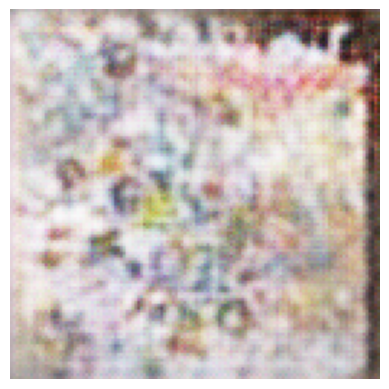

In [ ]:
# Si usaste tanh en la capa de salida, reescala a [0,1]
imagen_generada = 0.5 * imagen_generada + 0.5

# Mostrar imagen con matplotlib
plt.imshow(imagen_generada[0])
plt.axis('off')
plt.show()